# Faz 1 — Veri Hazırlık ve Manifest

**Amaç:** TR_ABDOMEN_RAD_EMERGENCY veri setini incele, `Bilgi.xlsx`'teki ham annotasyonları doğrula, 16 ham etiketi 6 üst sınıfa eşle ve `manifest.csv` üret.

**Adımlar**
1. Ortam ve yol kontrolü
2. `Bilgi.xlsx` keşfi (TRAIININGDATA + COMPETITIONDATA)
3. Ham etiket → 6 üst sınıf eşleme istatistikleri
4. Tek vaka üzerinde DICOM yükleme + HU pencereleme görseli
5. `build_manifest()` → `outputs/splits/manifest.csv`
6. Manifest doğrulama

## 1. Ortam ve Yol Kontrolü

In [1]:
import os, sys
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

DATA_ROOT = Path(os.environ.get("TR_ABDOMEN_BASE", r"D:/makale-pdf/Proje/abdomen"))
PROJE     = Path(os.environ.get("TR_ABDOMEN_PROJE", r"D:/makale-pdf/Proje"))
CODE      = Path(os.environ.get("TR_ABDOMEN_CODE",  r"D:/makale-pdf/Proje/code"))
EGITIM_DIR = Path(os.environ.get("ABDOMEN_TRAIN_DIR", DATA_ROOT / "Egitim Verisi"))
YARISMA_DIR = Path(os.environ.get("ABDOMEN_TEST_DIR", DATA_ROOT / "Test Verisi"))


sys.path.insert(0, str(CODE))

print("DATA_ROOT   :", DATA_ROOT, "→ var?", DATA_ROOT.exists())
print("EGITIM_DIR  :", EGITIM_DIR, "→ var?", EGITIM_DIR.exists())
print("Bilgi.xlsx  :", (DATA_ROOT / "Bilgi.xlsx").exists())
print("CODE/src    :", (CODE / "src").exists())
egitim_cases = sorted([d for d in EGITIM_DIR.iterdir() if d.is_dir()]) if EGITIM_DIR.exists() else []
print(f"\nEğitim vaka klasörü sayısı: {len(egitim_cases)}")
print("İlk 5 vaka:", [d.name for d in egitim_cases[:5]])

DATA_ROOT   : D:\makale-pdf\Proje\abdomen → var? True
EGITIM_DIR  : D:\makale-pdf\Proje\abdomen\Egitim Verisi → var? True
Bilgi.xlsx  : True
CODE/src    : True

Eğitim vaka klasörü sayısı: 736
İlk 5 vaka: ['20001', '20002', '20003', '20004', '20005']


## 2. Bilgi.xlsx Keşfi

In [2]:
import pandas as pd
xl = pd.ExcelFile(DATA_ROOT / "Bilgi.xlsx")
print("Sayfalar:", xl.sheet_names)
train_df = pd.read_excel(xl, sheet_name="TRAIININGDATA")
comp_df  = pd.read_excel(xl, sheet_name="COMPETITIONDATA")
print(f"\nTRAIININGDATA   : {len(train_df):,} annotasyon, {train_df['Case Number'].nunique()} vaka")
print(f"COMPETITIONDATA : {len(comp_df):,} annotasyon, {comp_df['Case Number'].nunique()} vaka")
print(f"Sütunlar: {list(train_df.columns)}")
train_df.head(5)

Sayfalar: ['COMPETITIONDATA', 'TRAIININGDATA']

TRAIININGDATA   : 28,134 annotasyon, 735 vaka
COMPETITIONDATA : 14,314 annotasyon, 357 vaka
Sütunlar: ['Case Number', 'Image Id', 'Type', 'Class', 'Data']


,Case Number,Image Id,Type,Class,Data
0,20001,100007,Bounding Box,ureteral stone,"251,290-262,302"
1,20001,100008,Bounding Box,ureteral stone,"251,291-261,301"
2,20001,100010,Boundary Slice,Kidney-Bladder,NaN
3,20002,100070,Boundary Slice,Kidney-Bladder,NaN
4,20002,100120,Bounding Box,Kidney stone,"337,276-345,282"


In [3]:
print('=== TRAIININGDATA — Type ===')
print(train_df['Type'].value_counts())
print('\n=== COMPETITIONDATA — Type ===')
print(comp_df['Type'].value_counts())

=== TRAIININGDATA — Type ===
Type
Bounding Box      24498
Boundary Slice     3636
Name: count, dtype: int64

=== COMPETITIONDATA — Type ===
Type
Bounding Box      10052
Boundary Slice     4262
Name: count, dtype: int64


In [4]:
print('=== TRAIININGDATA — Class (ilk 20) ===')
print(train_df['Class'].value_counts().head(20))

=== TRAIININGDATA — Class (ilk 20) ===
Class
Abdominal aortic aneurysm               8983
Compatible with acute pancreatitis      7128
Compatible with acute cholecystitis     5159
Gallbladder stone                       1439
Kidney stone                            1149
Abdominal aortic dissection              806
Abdominal Aorta                          733
Kidney-Bladder                           608
Pancreas                                 502
Gall bladder                             439
Colon                                    411
appendix                                 338
ureteral stone                           321
Compatible with acute appendicitis        60
Calcified diverticulum                    38
Compatible with acute diverticulitis      20
Name: count, dtype: int64


## 3. Ham Etiket → 6 Üst Sınıf Eşleme

In [5]:
from src.config import RAW_PATHOLOGY_TO_SUPER, SUPER_CLASSES, ANATOMICAL_TO_ID
print('6 ÜST SINIF:')
for i, s in enumerate(SUPER_CLASSES):
    print(f'  {i}: {s}')
print('\nHam patoloji → üst sınıf:')
for raw, sid in RAW_PATHOLOGY_TO_SUPER.items():
    print(f'  {raw:50s} → {sid} ({SUPER_CLASSES[sid]})')

6 ÜST SINIF:
  0: acute_cholecystitis
  1: kidney_ureter_stone
  2: acute_pancreatitis
  3: aortic_aneurysm_dissection
  4: acute_appendicitis
  5: acute_diverticulitis

Ham patoloji → üst sınıf:
  Compatible with acute cholecystitis                → 0 (acute_cholecystitis)
  Gallbladder stone                                  → 0 (acute_cholecystitis)
  Kidney stone                                       → 1 (kidney_ureter_stone)
  ureteral stone                                     → 1 (kidney_ureter_stone)
  Compatible with acute pancreatitis                 → 2 (acute_pancreatitis)
  Abdominal aortic aneurysm                          → 3 (aortic_aneurysm_dissection)
  Abdominal aortic dissection                        → 3 (aortic_aneurysm_dissection)
  Compatible with acute appendicitis                 → 4 (acute_appendicitis)
  Compatible with acute diverticulitis               → 5 (acute_diverticulitis)
  Calcified diverticulum                             → 5 (acute_diverticulitis)


In [6]:
all_classes = pd.concat([train_df['Class'], comp_df['Class']]).value_counts()
mapped = {c: cnt for c, cnt in all_classes.items() if c in RAW_PATHOLOGY_TO_SUPER}
anat   = {c: cnt for c, cnt in all_classes.items() if c in ANATOMICAL_TO_ID}
unmapped = {c: cnt for c, cnt in all_classes.items()
            if c not in RAW_PATHOLOGY_TO_SUPER and c not in ANATOMICAL_TO_ID}
print(f"Patoloji (eşlenen): {sum(mapped.values()):,} annot, {len(mapped)} sınıf")
print(f"Anatomik:           {sum(anat.values()):,} annot, {len(anat)} sınıf")
print(f"Eşlenmeyen:         {sum(unmapped.values()):,} annot")
for c, n in list(unmapped.items())[:10]:
    print(f'  {c}: {n}')

Patoloji (eşlenen): 35,155 annot, 10 sınıf
Anatomik:           7,293 annot, 6 sınıf
Eşlenmeyen:         0 annot


## 4. Tek Vaka Görsel Doğrulama (HU Pencereleme)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from src.dicom_utils import read_dicom, dicom_to_hu, hu_to_three_channel
from src.config import DEFAULT_WINDOWS

sample_row = train_df[train_df['Type'] == 'Bounding Box'].iloc[0]
case = int(sample_row['Case Number'])
img_id = int(sample_row['Image Id'])
dcm_path = EGITIM_DIR / str(case) / f"{img_id}.dcm"
print(f"Vaka {case}, kesit {img_id} | sınıf: {sample_row['Class']} | bbox: {sample_row['Data']}")
print(f"DICOM yolu: {dcm_path} (var: {dcm_path.exists()})")

ds = read_dicom(dcm_path)
hu = dicom_to_hu(ds)
rgb = hu_to_three_channel(hu, DEFAULT_WINDOWS)
print(f"HU shape: {hu.shape}, min={hu.min():.0f} max={hu.max():.0f}")
print(f"3 kanallı çıktı: {rgb.shape}")

Vaka 20001, kesit 100007 | sınıf: ureteral stone | bbox: 251,290-262,302
DICOM yolu: D:\makale-pdf\Proje\abdomen\Egitim Verisi\20001\100007.dcm (var: True)
HU shape: (512, 512), min=-1024 max=1215
3 kanallı çıktı: (512, 512, 3)


c:\Python38\lib\site-packages\pydicom\pixel_data_handlers\numpy_handler.py:250: UserWarning: The length of the pixel data in the dataset (1048576 bytes) indicates it contains excess padding. 524288 bytes will be removed from the end of the data
  warnings.warn(msg)


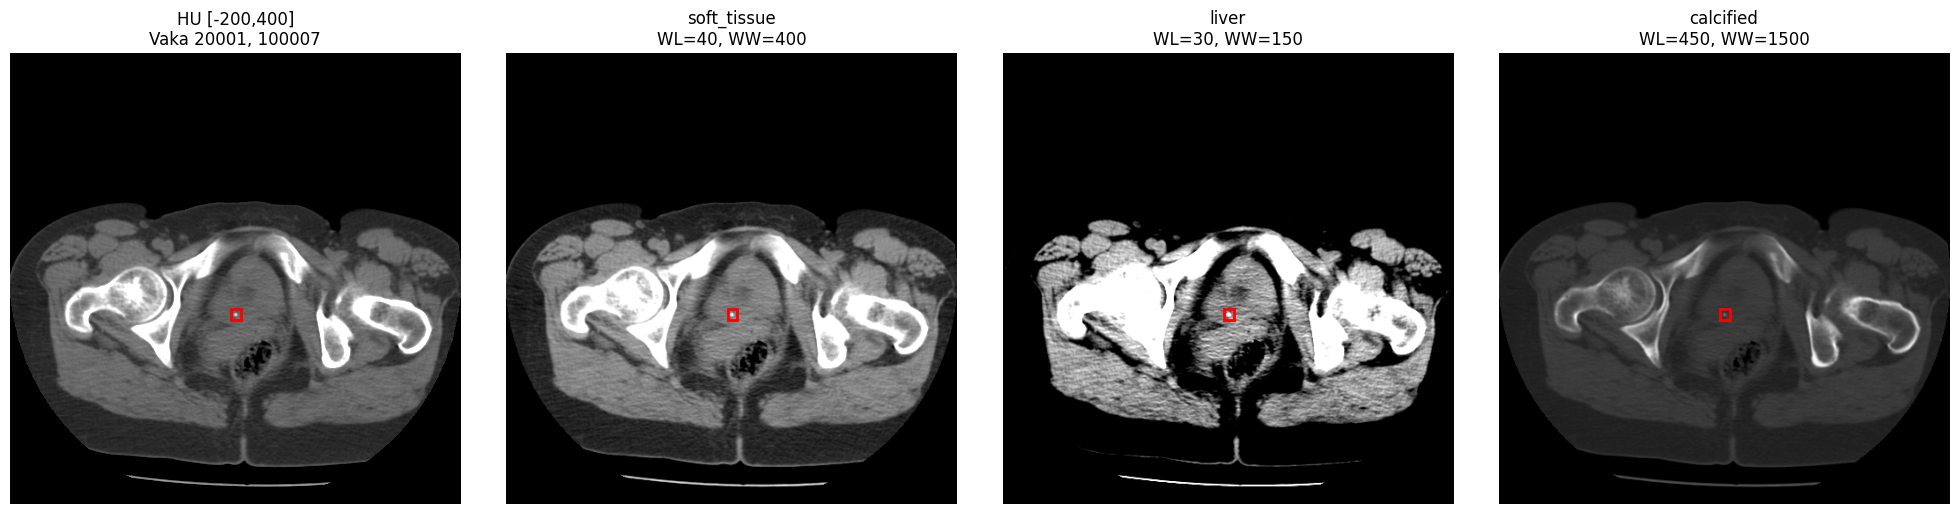

In [8]:
bbox_str = str(sample_row['Data'])
x1y1, x2y2 = bbox_str.split('-')
x1, y1 = [int(v) for v in x1y1.split(',')]
x2, y2 = [int(v) for v in x2y2.split(',')]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(hu, cmap='gray', vmin=-200, vmax=400)
axes[0].set_title(f'HU [-200,400]\nVaka {case}, {img_id}')
for i, w in enumerate(DEFAULT_WINDOWS):
    axes[i+1].imshow(rgb[..., i], cmap='gray')
    axes[i+1].set_title(f'{w.name}\nWL={w.level}, WW={w.width}')
for ax in axes:
    ax.add_patch(mpatches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2,
                                    edgecolor='red', facecolor='none'))
    ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Manifest Üretimi

In [9]:
from src.config import SPLIT_DIR
from src.preprocessing import build_manifest

out_path: Path = SPLIT_DIR / "manifest.csv"
manifest_path = out_path if out_path.exists() else build_manifest(out_path)
print('Manifest yazıldı:', manifest_path)

Manifest yazıldı: D:\makale-pdf\Proje\outputs1\splits\manifest.csv  (satır: 39268)
  BBox annotasyonu olan kesit  : 31,979  (YOLO girdisi)
  Boundary Slice olan kesit    : 7,898  (segmentasyon girdisi)
  Toplam BBox annotasyonu      : 34,550
  Toplam Boundary Slice annot. : 7,898
Manifest yazıldı: D:\makale-pdf\Proje\outputs1\splits\manifest.csv


In [10]:
manifest = pd.read_csv(manifest_path)
print(f'Toplam kesit: {len(manifest):,}')
print(f'Tekil vaka: {manifest["case"].nunique()}')
print(f'\nKaynak dağılımı:')
print(manifest['source'].value_counts())
manifest['has_path'] = manifest['super_labels'].fillna('').astype(str).str.len() > 0
manifest['has_bbox'] = manifest['bboxes'].fillna('').astype(str).str.len() > 0
print(f'\nÜst sınıf etiketli: {manifest["has_path"].sum():,}')
print(f'BBox\'lu kesit:      {manifest["has_bbox"].sum():,}')
manifest.head(5)

Toplam kesit: 39,268
Tekil vaka: 736

Kaynak dağılımı:
source
train    25886
comp     13382
Name: count, dtype: int64

Üst sınıf etiketli: 31,965
BBox'lu kesit:      31,965


,case,image_id,source,dicom_path,super_labels,bboxes,anatomical_boundary,n_bbox_anns,n_boundary_anns,has_path,has_bbox
0,20001,100007,train,D:\makale-pdf\Proje\abdomen\Egitim Verisi\2000...,1,"1,251,290,262,302",NaN,1,0,True,True
1,20001,100008,train,D:\makale-pdf\Proje\abdomen\Egitim Verisi\2000...,1,"1,251,291,261,301",NaN,1,0,True,True
2,20001,100010,train,D:\makale-pdf\Proje\abdomen\Egitim Verisi\2000...,NaN,NaN,Kidney-Bladder,0,1,False,False
3,20001,100014,comp,D:\makale-pdf\Proje\abdomen\Test Verisi\20001\...,NaN,NaN,Colon,0,1,False,False
4,20001,100017,comp,D:\makale-pdf\Proje\abdomen\Test Verisi\20001\...,NaN,NaN,Abdominal Aorta,0,1,False,False


In [11]:
from collections import Counter
cnt = Counter()
for v in manifest['super_labels'].fillna('').astype(str):
    if not v: continue
    for s in v.split(';'):
        if s.strip(): cnt[int(s)] += 1
print('Üst sınıf bazında BBox kesit sayısı:')
for sid, c in sorted(cnt.items()):
    print(f'  {sid} ({SUPER_CLASSES[sid]}): {c:,}')

Üst sınıf bazında BBox kesit sayısı:
  0 (acute_cholecystitis): 6,936
  1 (kidney_ureter_stone): 2,237
  2 (acute_pancreatitis): 8,696
  3 (aortic_aneurysm_dissection): 12,635
  4 (acute_appendicitis): 2,105
  5 (acute_diverticulitis): 371


## 6. Faz 1 Çıktı Özeti

| Çıktı | Yol |
|---|---|
| Manifest | `outputs/splits/manifest.csv` |

**Sonraki adım:** `Faz2_Split_Onisleme_1fold.ipynb`